In [1]:
import pandas as pd
df=pd.read_excel('premiums_rest.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [2]:
df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           9
Employment_Status        1
Income_Level             9
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [3]:
df.Gender.unique(),df.Region.unique(),df.Marital_status.unique(),df.BMI_Category.unique(),df.Smoking_Status.unique(),df.Employment_Status.unique(),df.Income_Level.unique(),df['Medical History'].unique(),df.Insurance_Plan.unique()

(array(['Male', 'Female'], dtype=object),
 array(['Northwest', 'Southeast', 'Northeast', 'Southwest'], dtype=object),
 array(['Unmarried', 'Married'], dtype=object),
 array(['Normal', 'Obesity', 'Overweight', 'Underweight'], dtype=object),
 array(['No Smoking', 'Regular', 'Occasional', nan, 'Does Not Smoke',
        'Not Smoking', 'Smoking=0'], dtype=object),
 array(['Salaried', 'Self-Employed', 'Freelancer', nan], dtype=object),
 array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object),
 array(['Diabetes', 'High blood pressure', 'No Disease',
        'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
        'High blood pressure & Heart disease', 'Diabetes & Thyroid',
        'Diabetes & Heart disease'], dtype=object),
 array(['Bronze', 'Silver', 'Gold'], dtype=object))

In [4]:
df['Genetical Risk']=0

In [5]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Genetical Risk
count,29904.000000,29904.000000,29904.000000,29904.000000,29904.0
mean,43.396536,2.380116,23.362059,20893.036684,0.0
std,13.411893,1.431140,24.737076,6935.844219,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15698.000000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [6]:
df.shape

(29904, 14)

In [7]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0


# Handing na Values

In [8]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [9]:
df.dropna(inplace=True) # size of dataset is very high and the na values are too low so we can drop na

In [10]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [11]:
print('Before: ',df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('After: ',df.duplicated().sum())

Before:  0
After:  0


In [12]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [13]:
df[df.number_of_dependants<0]['number_of_dependants']

1805    -1
2273    -1
3513    -3
3904    -1
4900    -1
5917    -3
7095    -3
7222    -3
7551    -1
9047    -1
9200    -1
9858    -3
10035   -1
10080   -1
13092   -1
13218   -1
13364   -3
13714   -3
14286   -3
15484   -3
15842   -3
16262   -3
16490   -3
17634   -3
18640   -1
18932   -1
19073   -3
19159   -1
19609   -3
20453   -1
20737   -1
21093   -3
21361   -3
23561   -3
24606   -1
25369   -1
26025   -1
26229   -1
27114   -1
27355   -1
27630   -3
27890   -1
27942   -1
28023   -3
28197   -1
28501   -1
28779   -1
29484   -1
29491   -1
29639   -1
Name: number_of_dependants, dtype: int64

In [14]:
df['number_of_dependants'].abs().loc[[402,2245,2323,2986,2756,5846]]

402     2
2245    1
2323    2
2986    1
2756    3
5846    3
Name: number_of_dependants, dtype: int64

In [15]:
df['number_of_dependants']=df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.385933,23.364184,20892.303821,0.0
std,13.412657,1.421137,24.740339,6936.813440,0.0
min,26.000000,0.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [16]:
numeric_cols=df.select_dtypes(['float64','int64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

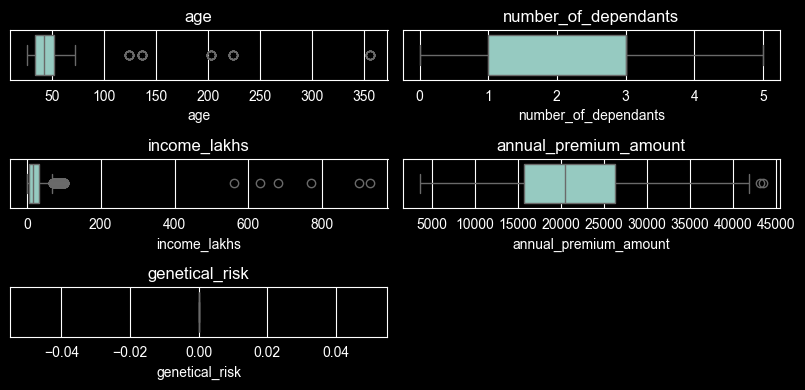

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
def get_iqr_bounds(col):
    q1,q3=col.quantile([0.25,0.75])
    iqr=q3-q1
    return (q1-1.5*iqr,q3+iqr*1.5)

In [19]:
df = df[df['age'] <= 100]

<Axes: xlabel='age'>

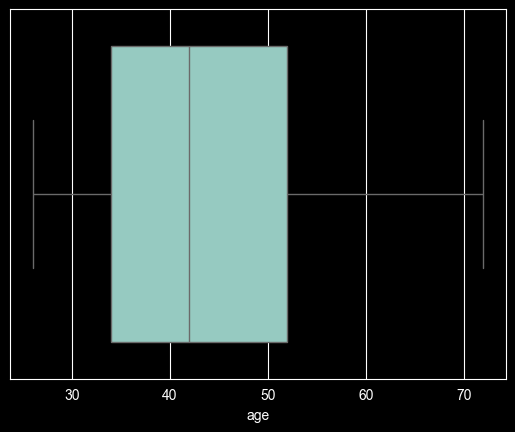

In [20]:
sns.boxplot(x=df['age'])

In [21]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,43.095380,2.387790,23.371530,20901.900563,0.0
std,11.041991,1.420641,24.751262,6928.457636,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15706.000000,0.0
50%,42.000000,3.000000,17.000000,20496.000000,0.0
75%,52.000000,3.000000,32.000000,26361.000000,0.0
max,72.000000,5.000000,930.000000,43471.000000,0.0


<Axes: xlabel='income_lakhs', ylabel='Count'>

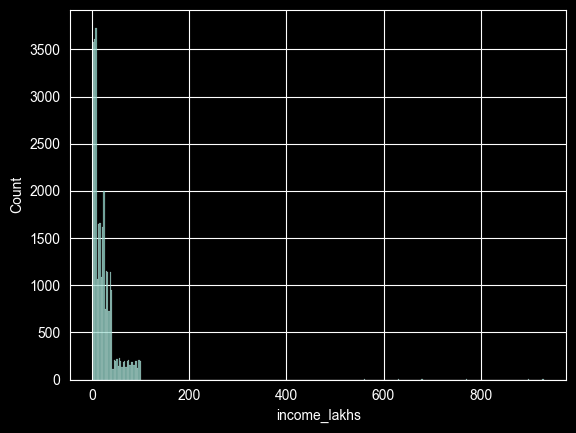

In [22]:
sns.histplot(df['income_lakhs'])

In [23]:
upper_income=get_iqr_bounds(df['income_lakhs'])[1] # the value we get is not that extreme so we try other things
quantile_threshold=df['income_lakhs'].quantile(0.999)
print(quantile_threshold)
df[df['income_lakhs']>quantile_threshold]['age'].count()

100.0


np.int64(6)

In [24]:
import numpy as np
df=df[df['income_lakhs']<=  quantile_threshold] # dropping the income greater than 100 because only 10 outliers

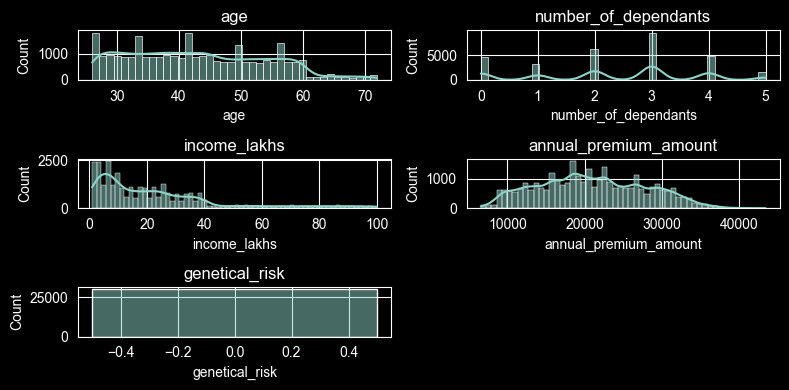

In [25]:
plt.figure(figsize=(8,4))
for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.histplot(x=df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

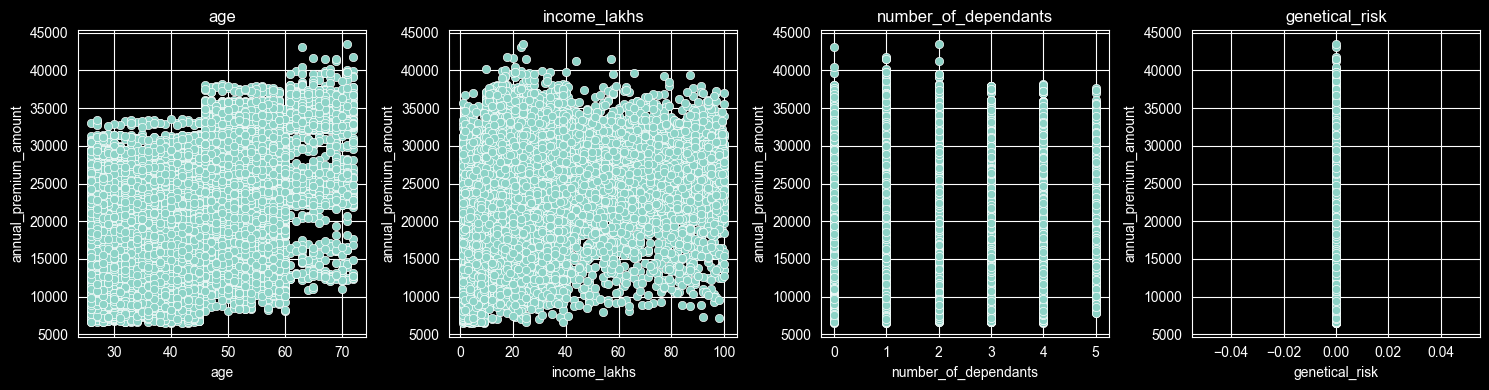

In [26]:
numeric_features = ['age','income_lakhs','number_of_dependants','genetical_risk']
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15,4))
for i, col in enumerate(numeric_features):
    sns.scatterplot(data=df, x=col, y='annual_premium_amount', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [27]:
categorical_col=[ 'gender', 'region', 'marital_status','bmi_category', 'smoking_status', 'employment_status',  'medical_history', 'insurance_plan',]
for col in categorical_col:
    print(df[col].unique())

['Male' 'Female']
['Northwest' 'Southeast' 'Northeast' 'Southwest']
['Unmarried' 'Married']
['Normal' 'Obesity' 'Overweight' 'Underweight']
['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
['Salaried' 'Self-Employed' 'Freelancer']
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
['Bronze' 'Silver' 'Gold']


In [28]:
df['smoking_status'].isna().sum()

np.int64(0)

In [29]:
df['smoking_status']=df['smoking_status'].replace({'Smoking=0':'No Smoking' ,'Does Not Smoke':'No Smoking','Not Smoking':'No Smoking'})

In [30]:
df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [31]:
df['smoking_status'].value_counts()

smoking_status
No Smoking    13483
Regular       11173
Occasional     5166
Name: count, dtype: int64

In [32]:
df['gender'].value_counts(normalize=True),df['gender'].isna().sum()

(gender
 Male      0.549125
 Female    0.450875
 Name: proportion, dtype: float64,
 np.int64(0))

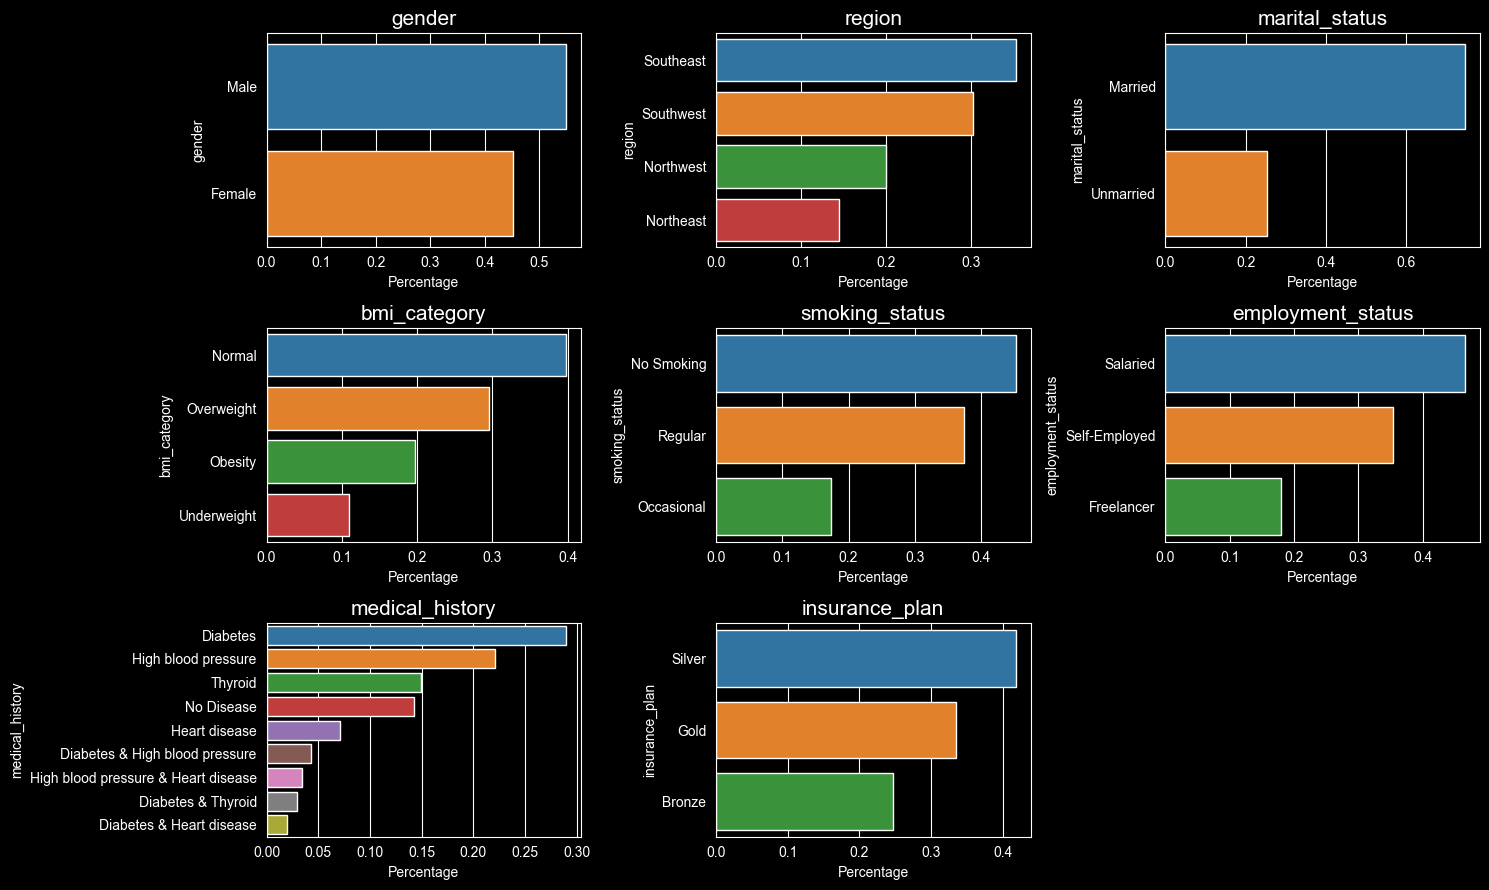

In [33]:
cols = categorical_col
n = len(cols)
rows = (n + 2) // 3   # calculate rows needed
fig, axes = plt.subplots(rows, 3, figsize=(15, 3*rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    pct_count = df[col].value_counts(normalize=True)
    sns.barplot(x=pct_count.values,y=pct_count.index, ax=axes[i],hue=pct_count.index,palette='tab10')
    axes[i].set_title(col,fontsize=15)
    axes[i].set_xlabel("Percentage")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [34]:
crosstab=pd.crosstab(df['income_level'],df['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,799,3554,4354
25L - 40L,301,2631,3142
<10L,6054,527,4341
> 40L,214,3287,618


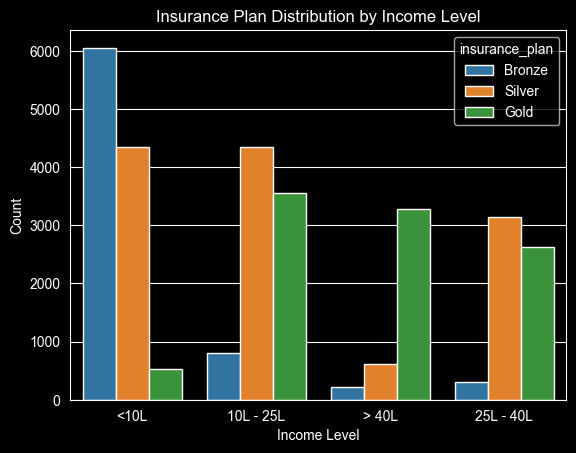

In [35]:
sns.countplot(data=df, x='income_level', hue='insurance_plan',palette='tab10')
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.title("Insurance Plan Distribution by Income Level")
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

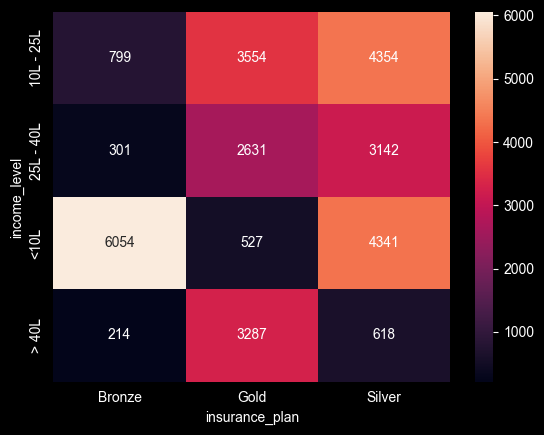

In [36]:
sns.heatmap(crosstab,annot=True,fmt="d")

In [37]:
df['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [38]:
df[['disease1','disease2']]=df['medical_history'].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
20651,42,Male,Southeast,Married,3,Underweight,Regular,Salaried,<10L,3,High blood pressure,Bronze,12444,0,high blood pressure,None
26284,51,Female,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,64,High blood pressure,Bronze,17885,0,high blood pressure,None
789,51,Male,Southeast,Unmarried,0,Overweight,Regular,Self-Employed,<10L,4,High blood pressure,Silver,23838,0,high blood pressure,None
23303,49,Female,Northeast,Married,3,Overweight,Occasional,Self-Employed,<10L,3,Heart disease,Silver,25476,0,heart disease,None
7063,46,Male,Northwest,Married,3,Overweight,No Smoking,Self-Employed,> 40L,54,Diabetes,Gold,28597,0,diabetes,None


In [39]:
df['disease1'].fillna('none',inplace=True)
df['disease2'].fillna('none',inplace=True)

In [40]:
risk_score={
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'thyroid':5,
    'no disease':0,
    'none':0
}

In [41]:
df['total_risk_score']=df['disease1'].map(risk_score)+df['disease2'].map(risk_score)

In [42]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score
27869,50,Female,Southwest,Married,4,Normal,No Smoking,Self-Employed,10L - 25L,19,Thyroid,Gold,26279,0,thyroid,none,5
2138,53,Female,Southwest,Married,4,Obesity,No Smoking,Self-Employed,10L - 25L,23,Diabetes,Gold,30446,0,diabetes,none,6
3625,45,Female,Northwest,Married,3,Underweight,Occasional,Salaried,<10L,4,High blood pressure,Bronze,10951,0,high blood pressure,none,6
2546,51,Male,Southwest,Married,4,Obesity,Regular,Self-Employed,<10L,7,High blood pressure,Silver,25891,0,high blood pressure,none,6
2491,46,Male,Northwest,Married,3,Underweight,No Smoking,Self-Employed,10L - 25L,14,Diabetes,Gold,26561,0,diabetes,none,6


In [43]:
min_score=df['total_risk_score'].min()
max_score=df['total_risk_score'].max()
df['normalized_score']=((df['total_risk_score']-min_score)/(max_score-min_score))

In [44]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_score
20319,29,Female,Northwest,Married,3,Underweight,No Smoking,Freelancer,25L - 40L,31,No Disease,Silver,14458,0,no disease,none,0,0.000000
19824,49,Male,Southwest,Married,2,Obesity,No Smoking,Self-Employed,> 40L,58,Thyroid,Gold,30869,0,thyroid,none,5,0.357143
3170,30,Male,Northwest,Married,5,Normal,No Smoking,Salaried,> 40L,100,High blood pressure,Gold,22144,0,high blood pressure,none,6,0.428571
6545,51,Male,Southwest,Married,4,Normal,Occasional,Salaried,10L - 25L,18,Diabetes,Bronze,11030,0,diabetes,none,6,0.428571
13759,29,Female,Southeast,Unmarried,1,Obesity,Regular,Self-Employed,10L - 25L,13,Diabetes,Bronze,16121,0,diabetes,none,6,0.428571


In [45]:
df2=df.copy()

In [46]:
df2['insurance_plan']=df2['insurance_plan'].map({'Bronze':1,'Silver':2,'Gold':3})

In [47]:
df2.insurance_plan.unique()

array([1, 2, 3])

In [48]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [49]:
df2['income_level']=df2['income_level'].map({'<10L':1, '10L - 25L':2,'25L - 40L':3, '> 40L':4})

In [50]:
df2['income_level'].unique()

array([1, 2, 4, 3])

In [51]:
nominal_cols=['gender', 'region', 'marital_status','bmi_category','smoking_status', 'employment_status']
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)

In [52]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,0,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,0,diabetes,none,...,0,0,0,1,0,0,1,0,0,1


In [53]:
df4=df3.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [54]:
correlation=df4.corr()
correlation

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
age,1.000000,-0.017614,0.033455,0.024253,0.310446,0.484715,NaN,0.002473,-0.003699,0.001752,-0.002130,-0.003622,-0.123857,0.014732,0.017585,0.005224,-0.053572,-0.126481,-0.198537,0.270621
number_of_dependants,-0.017614,1.000000,-0.000009,-0.000640,0.010334,0.015969,NaN,0.106168,-0.000594,-0.002981,0.000732,0.007047,-0.777352,0.019413,0.014560,-0.021186,0.011848,0.013306,0.012497,-0.015319
income_level,0.033455,-0.000009,1.000000,0.906027,0.575543,0.457965,NaN,0.009162,0.087234,-0.003207,0.001624,0.008060,-0.008038,-0.013072,0.000403,0.009439,-0.008517,0.027486,-0.153555,0.158281
income_lakhs,0.024253,-0.000640,0.906027,1.000000,0.491785,0.385215,NaN,0.002320,0.064060,-0.004417,0.000914,0.006266,-0.005109,-0.010316,0.001635,0.004484,-0.002957,0.018637,-0.115155,0.121798
insurance_plan,0.310446,0.010334,0.575543,0.491785,1.000000,0.882571,NaN,0.001329,0.069102,-0.000996,0.006580,-0.006797,-0.053047,0.014033,0.025969,-0.014648,-0.029196,-0.017796,-0.152740,0.185159
annual_premium_amount,0.484715,0.015969,0.457965,0.385215,0.882571,1.000000,NaN,0.209361,0.132898,-0.004529,0.007190,-0.005766,-0.103286,0.188450,0.086748,-0.053967,-0.059392,0.136671,-0.179511,0.226210
genetical_risk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
normalized_score,0.002473,0.106168,0.009162,0.002320,0.001329,0.209361,NaN,1.000000,-0.005953,-0.010381,0.002480,0.005633,-0.140899,-0.010069,-0.004903,0.006440,0.005484,0.003338,-0.009321,0.014835
gender_Male,-0.003699,-0.000594,0.087234,0.064060,0.069102,0.132898,NaN,-0.005953,1.000000,-0.003620,-0.004893,0.004782,0.001761,-0.020570,0.103029,-0.029880,-0.096120,0.372381,0.004947,0.002606
region_Northwest,0.001752,-0.002981,-0.003207,-0.004417,-0.000996,-0.004529,NaN,-0.010381,-0.003620,1.000000,-0.369870,-0.329590,0.001498,0.001041,0.000390,-0.007454,-0.000612,0.001156,0.000872,0.000298


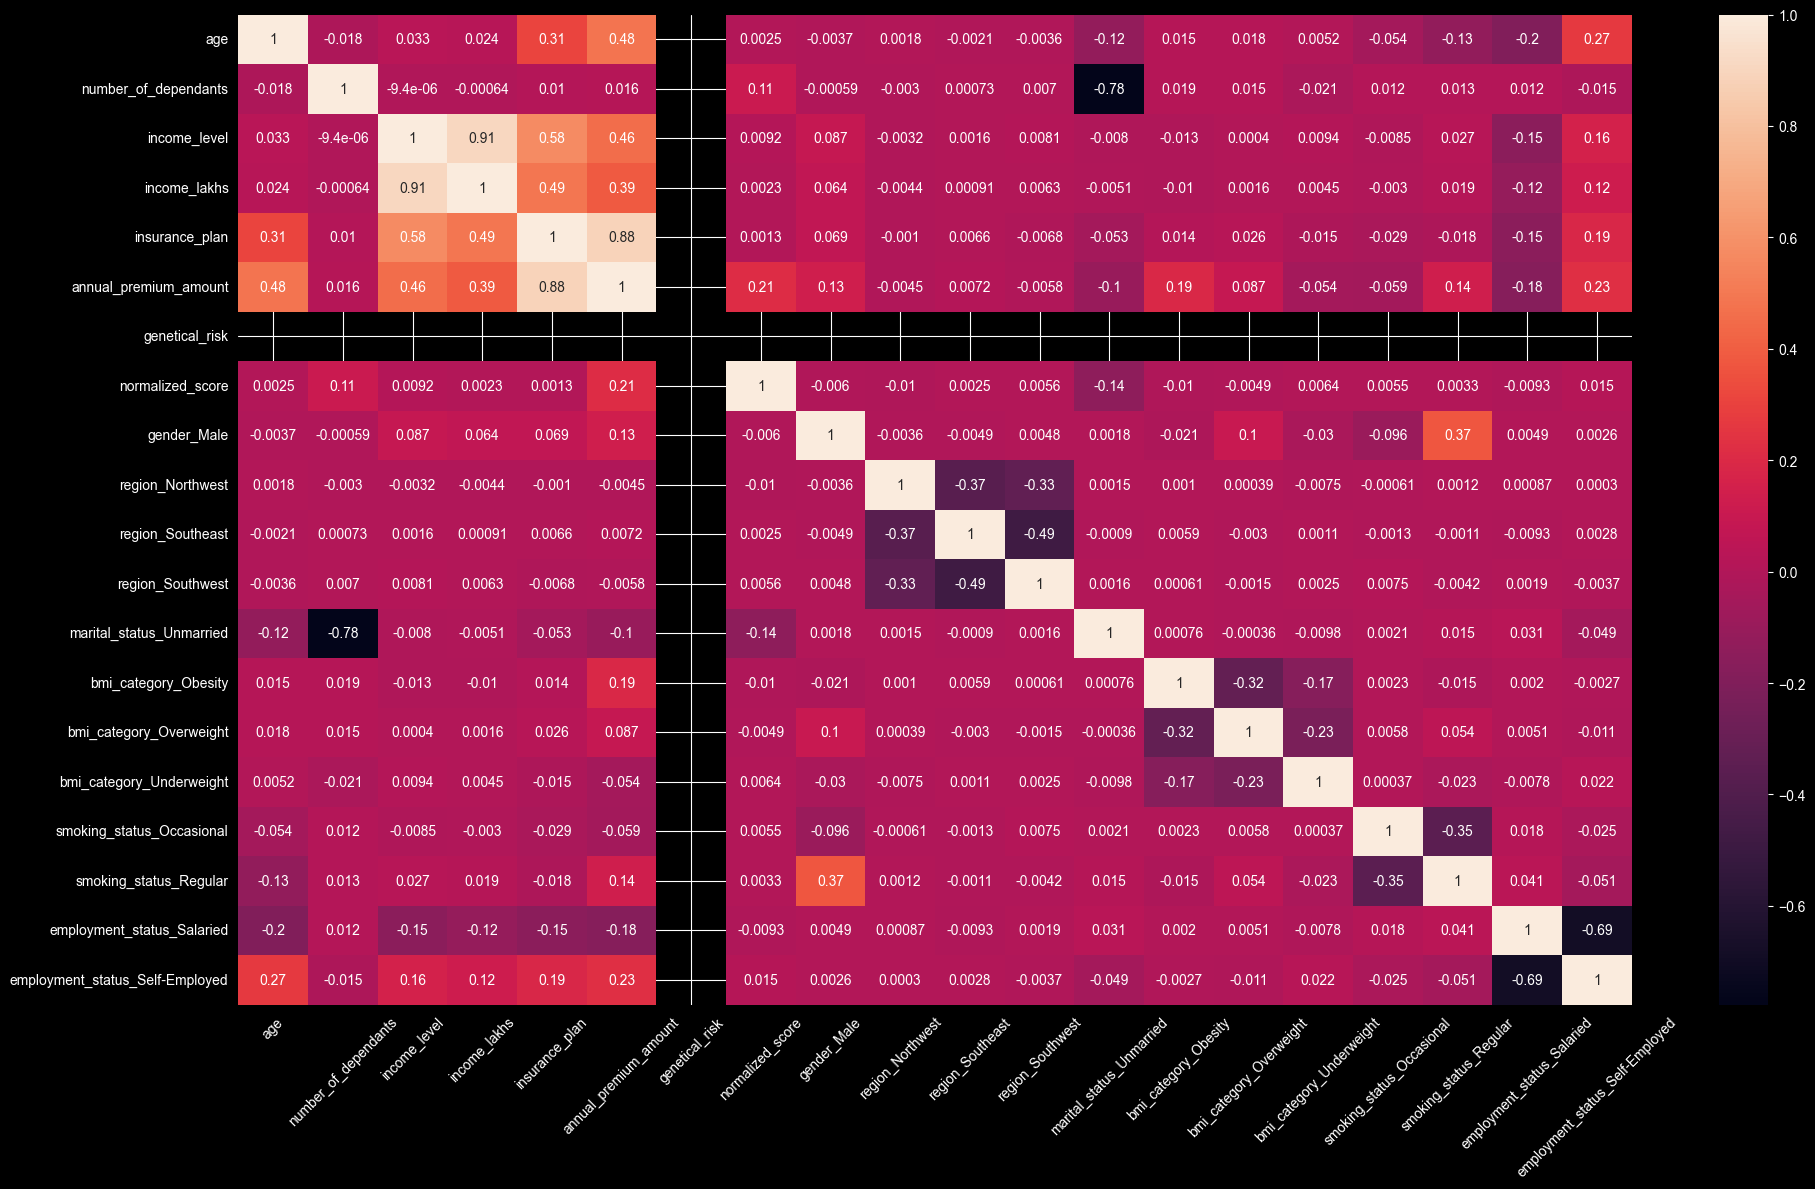

In [55]:
plt.figure(figsize=(20,12))
sns.heatmap(correlation,annot=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
x=df4.drop(['annual_premium_amount'],axis=1)
y=df4['annual_premium_amount']
from sklearn.preprocessing import MinMaxScaler
cols_to_scale=['age', 'number_of_dependants', 'income_level', 'income_lakhs','insurance_plan','genetical_risk']
scalar=MinMaxScaler()
x[cols_to_scale]=scalar.fit_transform(x[cols_to_scale])
x.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.0,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.0,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.0,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.0,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.0,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.0,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif(data):
    vif_df=pd.DataFrame()
    vif_df['features']=data.columns
    vif_df['vif']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [58]:
vif(x)

C:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,features,vif
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,genetical_risk,NaN
6,normalized_score,3.810619
7,gender_Male,2.599098
8,region_Northwest,2.123965
9,region_Southeast,2.980842


In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()
model_lr.fit(x_train,y_train)
train_score=model_lr.score(x_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.9529787900333265, 0.9561027322472136)

In [61]:
x.columns,model_lr.coef_

(Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
        'insurance_plan', 'genetical_risk', 'normalized_score', 'gender_Male',
        'region_Northwest', 'region_Southeast', 'region_Southwest',
        'marital_status_Unmarried', 'bmi_category_Obesity',
        'bmi_category_Overweight', 'bmi_category_Underweight',
        'smoking_status_Occasional', 'smoking_status_Regular',
        'employment_status_Salaried', 'employment_status_Self-Employed'],
       dtype='object'),
 array([ 6.98643551e+03, -1.25729896e+03, -3.90245330e+02, -2.74974354e+02,
         1.49104836e+04, -9.09494702e-13,  6.02989503e+03,  7.22034831e+01,
        -6.11858764e+01, -2.35429448e+01, -3.03477672e+01, -6.89545509e+02,
         3.93144057e+03,  1.99191074e+03,  6.04878914e+02,  8.51004596e+02,
         2.81471455e+03, -8.06768379e+01,  2.49380138e+02]))

In [62]:
feature_importance=pd.DataFrame(model_lr.coef_,index=x.columns,columns=['coefficient'])
feature_importance.sort_values(by='coefficient',ascending=True,inplace=True)
feature_importance

,coefficient
number_of_dependants,-1.257299e+03
marital_status_Unmarried,-6.895455e+02
income_level,-3.902453e+02
income_lakhs,-2.749744e+02
employment_status_Salaried,-8.067684e+01
region_Northwest,-6.118588e+01
region_Southwest,-3.034777e+01
region_Southeast,-2.354294e+01
genetical_risk,-9.094947e-13
gender_Male,7.220348e+01


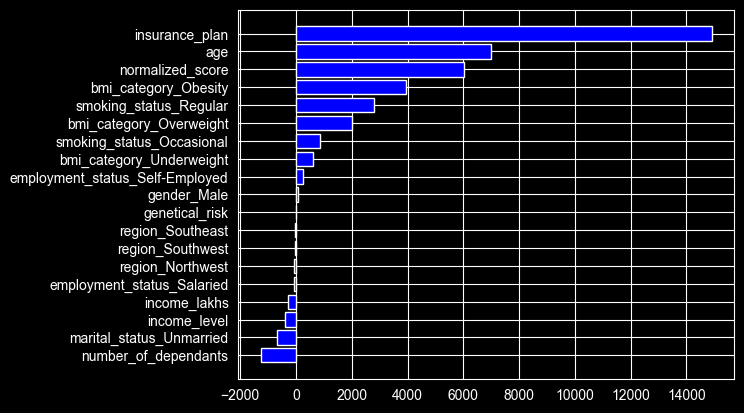

In [63]:
plt.barh(feature_importance.index,feature_importance['coefficient'],color='blue')
plt.show()

In [64]:
from sklearn.linear_model import Ridge
model_rg=Ridge()
model_rg.fit(x_train,y_train)
train_score=model_rg.score(x_train,y_train)
test_score=model_rg.score(x_test,y_test)
train_score,test_score

(0.9529786551819859, 0.9561038151984955)

In [65]:
from sklearn.tree import DecisionTreeRegressor
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train,y_train)
train_score=model_dt.score(x_train,y_train)
test_score=model_dt.score(x_test,y_test)
train_score,test_score

(0.9999926938701548, 0.9960959997061263)

In [66]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error
model_xg=XGBRegressor()
model_xg.fit(x_train,y_train)
y_pred=model_xg.predict(x_test)
train_score=model_xg.score(x_train,y_train)
test_score=model_xg.score(x_test,y_test)
train_score,test_score,mean_squared_error(y_test,y_pred),root_mean_squared_error(y_test,y_pred)

(0.9986041188240051, 0.9980814456939697, 93431.7578125, 305.66607666015625)

In [67]:
from sklearn.model_selection import GridSearchCV
params={
    "n_estimators":  [20,40,50],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,4,5]
}
grid=GridSearchCV(estimator=model_xg,param_grid=params,scoring='r2',cv=5,n_jobs=-1)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [20, 40, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [68]:
grid.score(x_test,y_test)

0.9981790781021118

In [69]:
grid.best_score_

np.float64(0.9980831146240234)

In [70]:
best_model=grid.best_estimator_

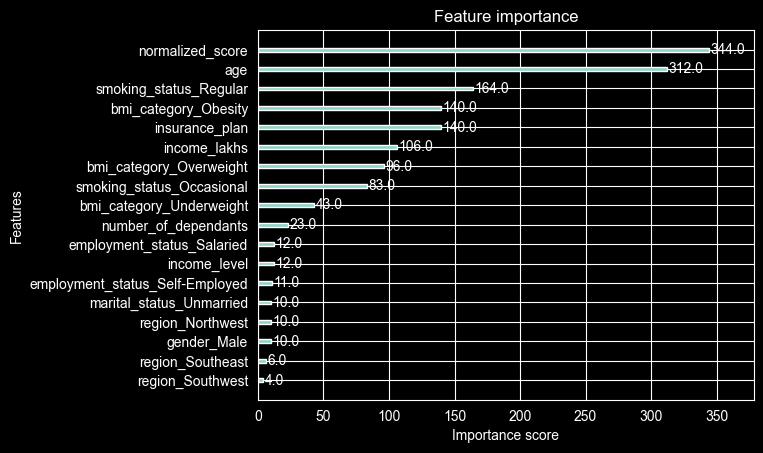

In [71]:
import xgboost as xgb
xgb.plot_importance(best_model)
plt.show()

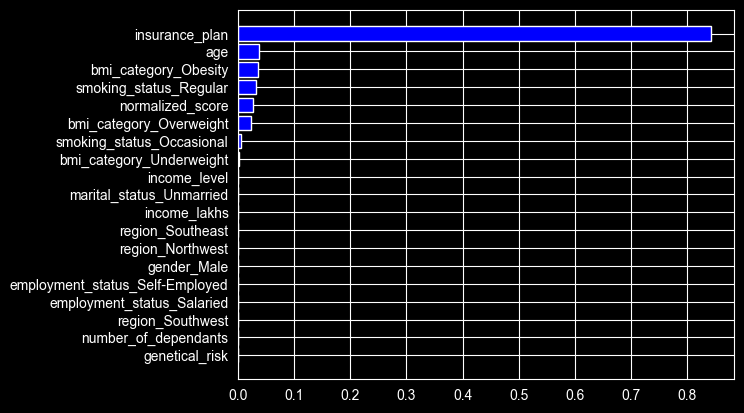

In [72]:
feature_importance=pd.DataFrame(best_model.feature_importances_,columns=['coefficient'],index=x_test.columns)
feature_importance.sort_values(by='coefficient',ascending=True,inplace=True)
plt.barh(feature_importance.index,feature_importance['coefficient'],color='blue')
plt.show()

In [73]:
y_pred=best_model.predict(x_test)
residual=y_pred-y_test
residual_pct=residual*100/y_test
result_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residual,
    'diff_pct':residual_pct
})
result_df.head()

,actual,predicted,diff,diff_pct
5495,30838,31029.240234,191.240234,0.620145
582,26306,26425.207031,119.207031,0.453155
281,17983,17539.373047,-443.626953,-2.466924
15443,19345,19041.398438,-303.601562,-1.569406
24281,33317,33545.375000,228.375000,0.685461


<Axes: xlabel='diff_pct', ylabel='Count'>

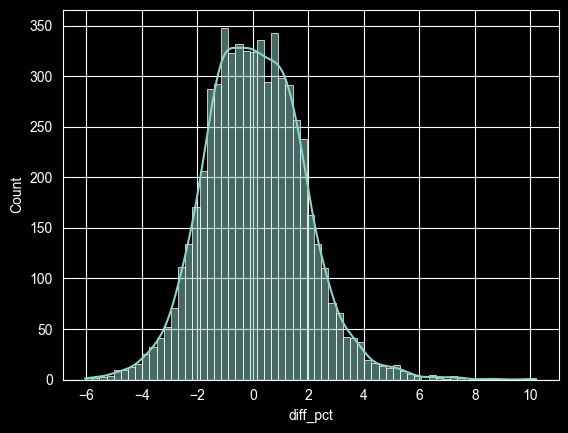

In [74]:
sns.histplot(result_df['diff_pct'],kde=True)

In [75]:
extreme_error_threshold=10
extreme_result_df=result_df[abs(result_df['diff_pct'])>extreme_error_threshold]
extreme_result_df.shape

(2, 4)

In [76]:
extreme_error_pct=extreme_result_df.shape[0]*100/result_df.shape[0]
extreme_error_pct

0.03352891869237217

In [77]:
result_df[np.abs(result_df['diff_pct'])>50].sort_values(by='diff_pct',ascending=False)

,actual,predicted,diff,diff_pct


In [78]:
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
6137,0.369565,0.2,0.0,0.040404,0.0,0.0,0.0,1,0,0,1,1,0,0,0,0,0,0,0
8270,0.282609,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,1,0


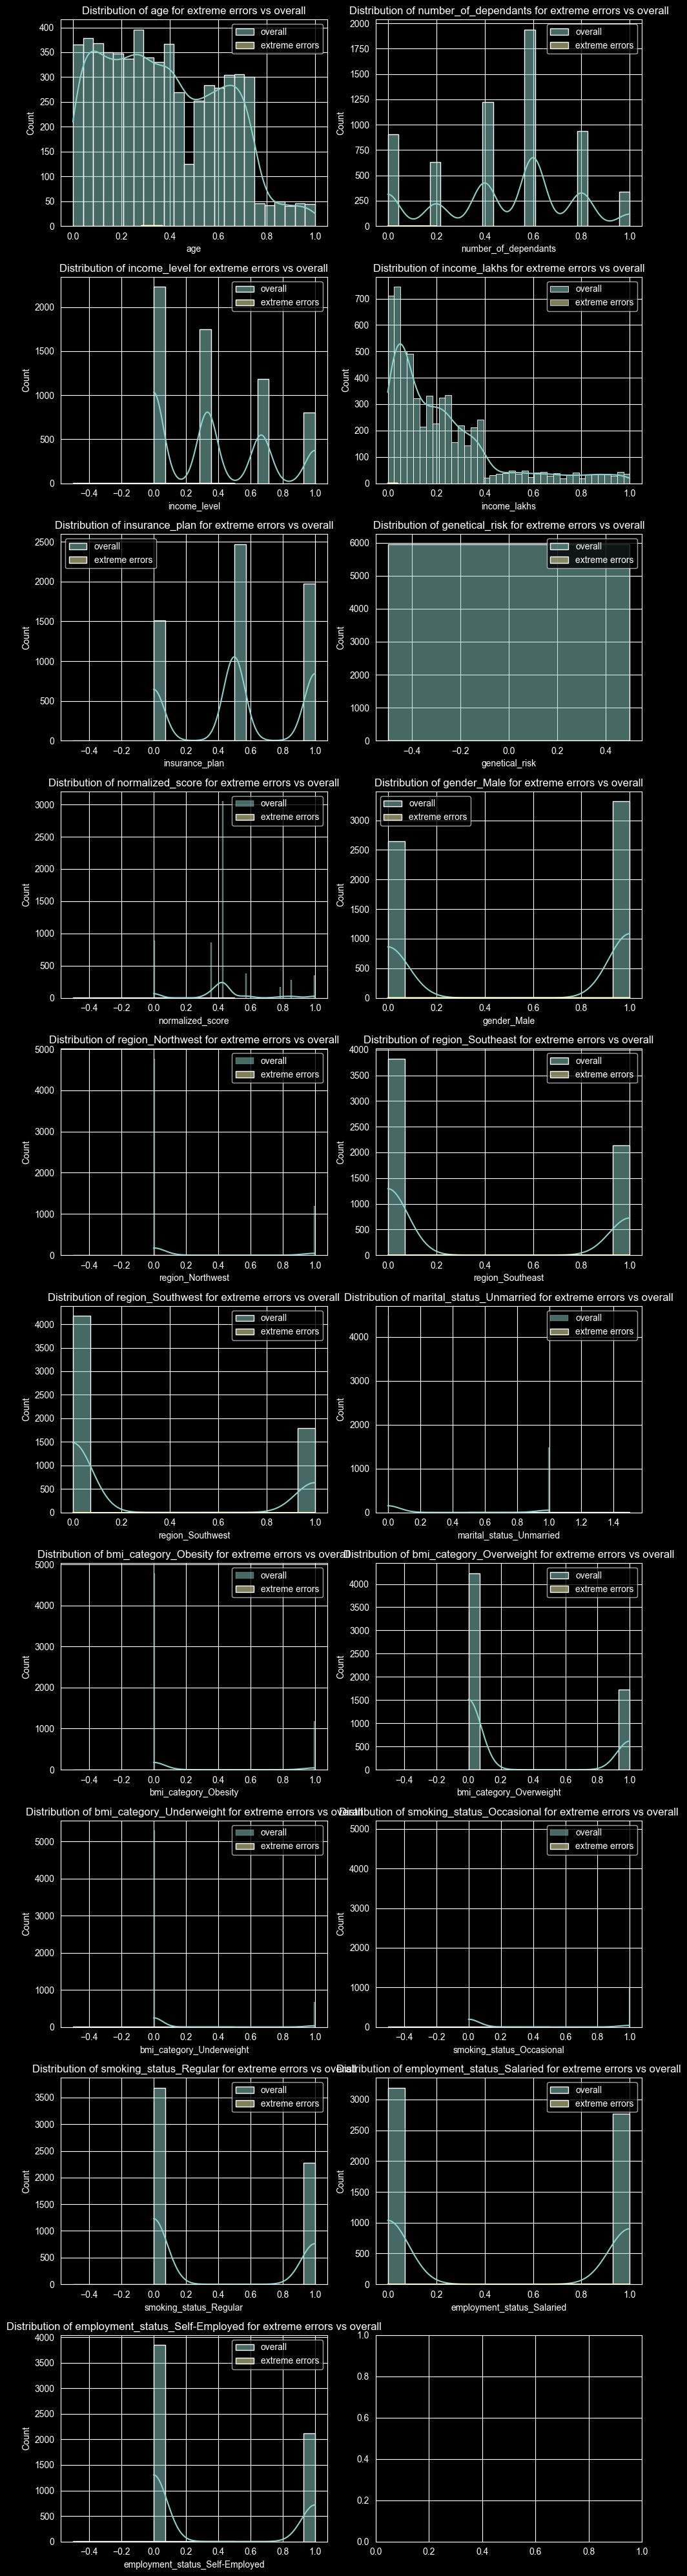

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cols = 2
rows = int(np.ceil(len(x_test.columns) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols,4*rows))
axes = axes.flatten()
for i, feature in enumerate(x_test.columns):
    sns.histplot(x_test[feature], kde=True, label='overall', ax=axes[i])
    sns.histplot(extreme_error_df[feature], kde=True, label='extreme errors', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} for extreme errors vs overall')
    axes[i].legend()
plt.tight_layout()
plt.show()

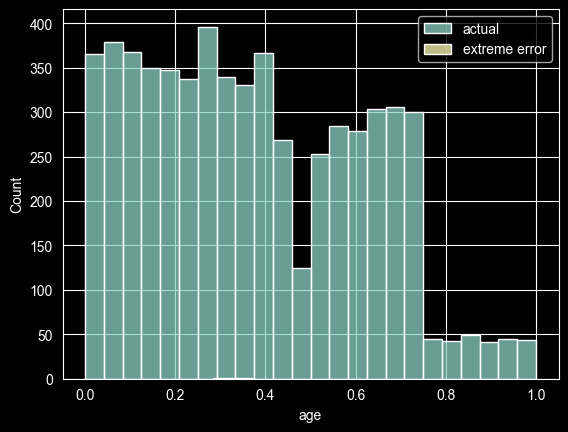

In [80]:
sns.histplot(x_test.age,label='actual')
sns.histplot(extreme_error_df.age,label='extreme error')
plt.legend()
plt.show()

In [81]:
df_reversed=pd.DataFrame(scalar.inverse_transform(extreme_error_df[cols_to_scale]),columns=cols_to_scale,index=extreme_error_df.index)
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
6137,43.0,1.0,1.0,5.0,1.0,0.0
8270,39.0,0.0,1.0,1.0,1.0,0.0


<Axes: xlabel='age', ylabel='Count'>

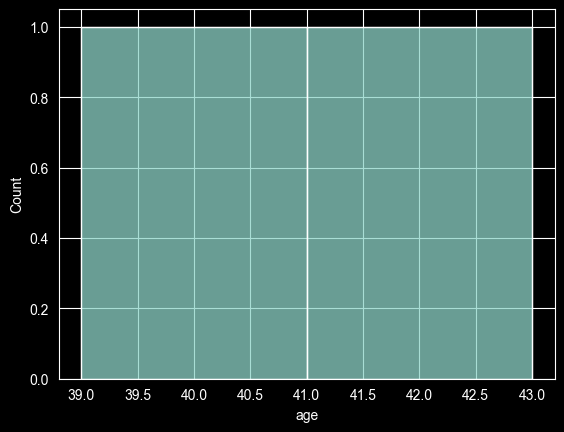

In [82]:
sns.histplot(df_reversed['age'])

In [83]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
count,2.000000,2.000000,2.0,2.000000,2.0,2.0
mean,41.000000,0.500000,1.0,3.000000,1.0,0.0
std,2.828427,0.707107,0.0,2.828427,0.0,0.0
min,39.000000,0.000000,1.0,1.000000,1.0,0.0
25%,40.000000,0.250000,1.0,2.000000,1.0,0.0
50%,41.000000,0.500000,1.0,3.000000,1.0,0.0
75%,42.000000,0.750000,1.0,4.000000,1.0,0.0
max,43.000000,1.000000,1.0,5.000000,1.0,0.0


In [84]:
extreme_error_df.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,2.000000,2.000000,2.0,2.000000,2.0,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,2.0,2.0,2.0,2.0,2.0,2.000000,2.0
mean,0.326087,0.100000,0.0,0.020202,0.0,0.0,0.0,0.500000,0.0,0.500000,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.0
std,0.061488,0.141421,0.0,0.028570,0.0,0.0,0.0,0.707107,0.0,0.707107,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.0
min,0.282609,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
25%,0.304348,0.050000,0.0,0.010101,0.0,0.0,0.0,0.250000,0.0,0.250000,0.250000,1.0,0.0,0.0,0.0,0.0,0.0,0.250000,0.0
50%,0.326087,0.100000,0.0,0.020202,0.0,0.0,0.0,0.500000,0.0,0.500000,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.0
75%,0.347826,0.150000,0.0,0.030303,0.0,0.0,0.0,0.750000,0.0,0.750000,0.750000,1.0,0.0,0.0,0.0,0.0,0.0,0.750000,0.0
max,0.369565,0.200000,0.0,0.040404,0.0,0.0,0.0,1.000000,0.0,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0


# export model

In [85]:
from joblib import dump
dump(best_model,'artifacts/model_rest.joblib')
scalar_with_cols={
    'scalar':scalar,
    'cols_to_scale':cols_to_scale,
}
dump(scalar_with_cols,'artifacts/scaler_rest.joblib')

['artifacts/scaler_rest.joblib']

In [86]:
scalar_with_cols={
    'scalar':scalar,
    'cols_to_scale':cols_to_scale,
}
scalar_with_cols

{'scalar': MinMaxScaler(),
 'cols_to_scale': ['age',
  'number_of_dependants',
  'income_level',
  'income_lakhs',
  'insurance_plan',
  'genetical_risk']}

In [87]:
x_test.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'genetical_risk', 'normalized_score', 'gender_Male',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [88]:
x_test.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
5495,0.021739,0.8,1.000000,0.838384,1.0,0.0,0.785714,1,0,0,1,0,1,0,0,0,1,1,0
582,0.695652,0.8,0.000000,0.000000,0.5,0.0,1.000000,0,0,1,0,0,1,0,0,0,0,0,1
281,0.195652,0.8,0.666667,0.252525,0.5,0.0,0.428571,0,0,1,0,0,0,1,0,0,0,1,0
15443,0.152174,0.0,0.666667,0.252525,0.5,0.0,0.428571,0,0,1,0,1,0,0,1,0,1,0,1
24281,0.695652,1.0,0.666667,0.282828,1.0,0.0,0.357143,0,0,1,0,0,1,0,0,0,1,0,1


In [89]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,diabetes,none,6,0.428571
